# Suma de dos dados

## Version 1

Esta version del codigo es la más simple. Implementa:

$$
\hat{p}_N=\frac{\text { favorables acumulados }}{N}
$$

y

$$
\operatorname{error}_N=\left|\hat{p}_N-\frac{1}{3}\right|
$$

Esta es una versión muy intutiva y simple y como usa una sola corrida, puedes llevarlo a Ns muy grandes como 
N=100000 o más sin que el código se vuelva torpe o innecesariamente lento.

Probabilidad teórica        = 0.333333
Probabilidad estimada sim = 0.331200
Error absoluto sim       = 0.002133


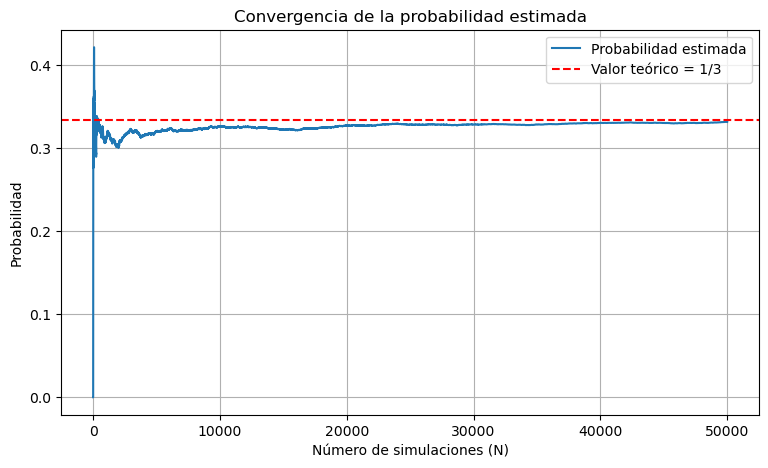

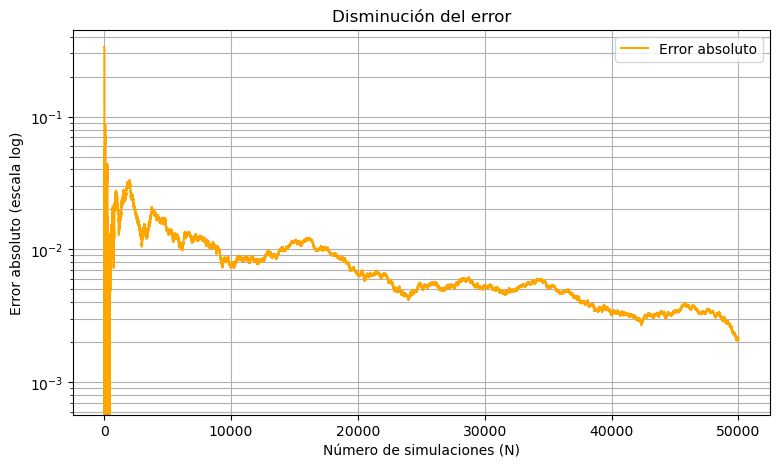

In [5]:
import random
import matplotlib.pyplot as plt

N_max = 50000
p_teorica = 1 / 3

random.seed(123)

probabilidades = []
errores = []
favorables = 0

for N in range(1, N_max + 1):
    if (random.randint(1, 6) + random.randint(1, 6)) % 3 == 0:
        favorables += 1

    p_est = favorables / N
    probabilidades.append(p_est)
    errores.append(abs(p_est - p_teorica))

print(f"Probabilidad teórica        = {p_teorica:.6f}")
print(f"Probabilidad estimada sim = {probabilidades[-1]:.6f}")
print(f"Error absoluto sim       = {errores[-1]:.6f}")

valores_N = range(1, N_max + 1)

plt.figure(figsize=(9, 5))
plt.plot(valores_N, probabilidades, label="Probabilidad estimada")
plt.axhline(p_teorica, color="red", linestyle="--", label="Valor teórico = 1/3")
plt.xlabel("Número de simulaciones (N)")
plt.ylabel("Probabilidad")
plt.title("Convergencia de la probabilidad estimada")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(valores_N, errores, label="Error absoluto", color="orange")
plt.yscale("log")
plt.xlabel("Número de simulaciones (N)")
plt.ylabel("Error absoluto (escala log)")
plt.title("Disminución del error")
plt.legend()
plt.grid(True, which="both")
plt.show()

Para el error vemos implementada una escala logarítmica. ¿Por que?. Pues bien, porque el error suele hacerse muy pequeño conforme crece N.
Si lo graficamos en escala normal, llega un punto donde al inicio se ve grande pero después parece casi pegado al eje, y ya no distingues bien cómo sigue disminuyendo.

En cambio, con escala logarítmica podemos ver mejor cambios pequeños, se pueden comparar órdenes de magnitud, y se aprecia mejor la tendencia decreciente del error.

De hecho, no se ve igual pasar de:

$$
10^{-1} \rightarrow 10^{-2}
$$

Que de

$$
10^{-2} \rightarrow 10^{-3}
$$

Aunque en ambos casos el error se redujo "10 veces". La escala log lo muestra de manera mucho más bonita e informativa.

Sin embargo, podemos hacer esta simulacion de los eventos un poco mas precisa y "elegante"

## Versión 2

Como en ejemplos pasados, usaremos una versión de método de Monte Carlo ya que este método nos ayuda a manejar mejor la pseudo aletoriedad para muchisimas repeticiones de un experimento.

A groso modo, el procedimiento es:

- Por medio de lazos, se simulan repetidamente lanzamientos de dos dados independientes usando números aleatorios uniformes entre 1 y 6.

- En cada simulación se calcula la suma de los dos dados.

- Se verifica si la suma es divisible entre 3.

- Se lleva un contador de cuántas veces ocurre este evento favorable.

- S e calcula laa probabilidad estimada después de N simulaciones promediando

$$
\hat{p}_N=\frac{\text { casos favorables }}{N}
$$

-  A medida que crece $N$, se guarda la probabilidad estimada y el error respecto al valor teórico $1 / 3$

Simulación Monte Carlo: Dos dados y suma divisible entre 3
-----------------------------------
Probabilidad teórica        = 0.333333
Probabilidad estimada final = 0.331191
Error absoluto final        = 0.002142
N total de simulaciones     = 50000


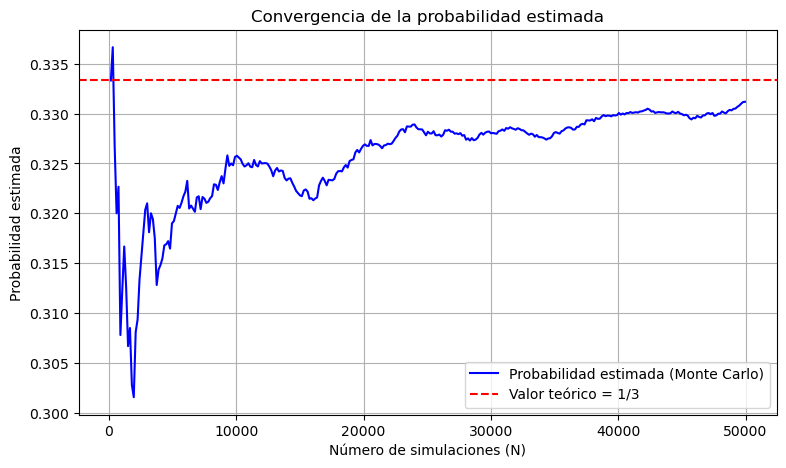

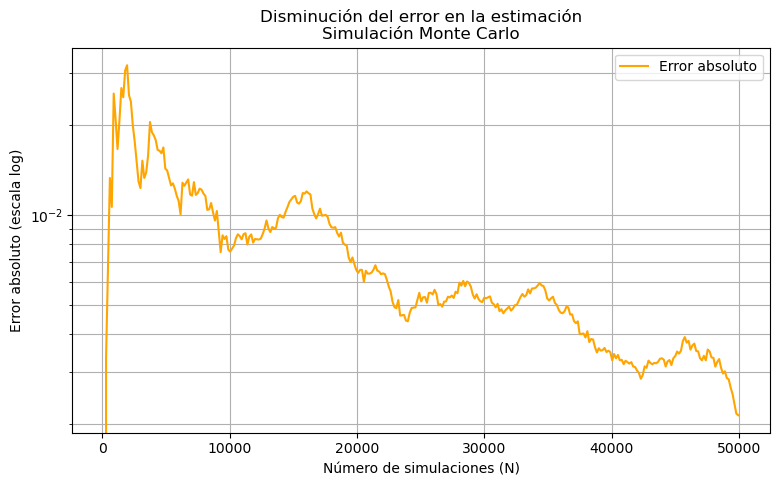

In [7]:
import random
import matplotlib.pyplot as plt

# Parámetros
N_max = 50000       # número máximo de simulaciones
paso = 150          # cada cuántas simulaciones guardamos datos
p_teorica = 1 / 3   # probabilidad teórica

# Fijamos semilla para reproducibilidad
random.seed(123)

# Simulación Monte Carlo acumulada
valores_N = []
probabilidades = []
errores = []

favorables = 0

for N in range(1, N_max + 1):

    dado1 = random.randint(1, 6)
    dado2 = random.randint(1, 6)

    if (dado1 + dado2) % 3 == 0:
        favorables += 1

    # guardamos datos cada cierto número de pasos
    if N % paso == 0:
        p_est = favorables / N
        error = abs(p_est - p_teorica)

        valores_N.append(N)
        probabilidades.append(p_est)
        errores.append(error)

# Resultados finales
print("Simulación Monte Carlo: Dos dados y suma divisible entre 3")
print("-----------------------------------")
print(f"Probabilidad teórica        = {p_teorica:.6f}")
print(f"Probabilidad estimada final = {probabilidades[-1]:.6f}")
print(f"Error absoluto final        = {errores[-1]:.6f}")
print(f"N total de simulaciones     = {N_max}")



# Gráfica de la probabilidad estimada
plt.figure(figsize=(9,5))

plt.plot(valores_N, probabilidades,
         label="Probabilidad estimada (Monte Carlo)",
         color="blue")

plt.axhline(p_teorica,
            color="red",
            linestyle="--",
            label="Valor teórico = 1/3")

plt.xlabel("Número de simulaciones (N)")
plt.ylabel("Probabilidad estimada")

plt.title("Convergencia de la probabilidad estimada")
plt.legend()
plt.grid(True)
plt.show()


# Gráfica del error absoluto
plt.figure(figsize=(9,5))

plt.plot(valores_N, errores,
         label="Error absoluto",
         color="orange")

plt.yscale('log')  # escala logarítmica

plt.xlabel("Número de simulaciones (N)")
plt.ylabel("Error absoluto (escala log)")

plt.title("Disminución del error en la estimación\n"
          "Simulación Monte Carlo")

plt.legend()
plt.grid(True, which="both")

plt.show()

Esta versión del código es en términos generales, más eficiente porque cada simulación requiere muy pocas operaciones y no guarda datos innecesarios. Ademñas, por Monte Carlo, usa una simulación acumulada, asi evitamos repetir experimentos desde cero y solo guarda resultados cada cierto número de pasos ( paso )

El costo computacional crece aproximadamente de forma lineal con $N$ :

$$
\text { costo } \sim O(N)
$$

Lo que permite ejecutar simulaciones con decenas o cientos de miles de experimentos sin problemas.